# Week 3 — Model Selection & Regularization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahdiabolghasemi/Introduction-To-Machine-Learning/blob/DSB102-S2-2026/Workshops/Week3-lab-Q.ipynb)


**Topics:** Forward stepwise, Ridge, Lasso, cross-validation

---
### Setup — run this cell first

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
import warnings; warnings.filterwarnings('ignore')

# First, we do some preprocessing on the data
# Things like normalize the model using the standard scaler 
# We have RidgeCV and LassoCV for variable seleciton and feature selection
# We have feature selection 

In [2]:
import os, urllib.request

# Load Hitters baseball salary dataset (ISLR/ISLP classic dataset)
try:
    from ISLP import load_data          # pre-installed on Colab
    df = load_data('Hitters').reset_index(drop=True)
except ImportError:
    if not os.path.exists('Hitters.csv'):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/intro-stat-learning/'
            'ISLP/main/ISLP/data/Hitters.csv',
            'Hitters.csv')
    df = pd.read_csv('Hitters.csv', index_col=0)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 322 entries, 293 to 631
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Hits       322 non-null    int64  
 1   HmRun      322 non-null    int64  
 2   Runs       322 non-null    int64  
 3   RBI        322 non-null    int64  
 4   Walks      322 non-null    int64  
 5   Years      322 non-null    int64  
 6   CAtBat     322 non-null    int64  
 7   CHits      322 non-null    int64  
 8   CHmRun     322 non-null    int64  
 9   CRuns      322 non-null    int64  
 10  CRBI       322 non-null    int64  
 11  CWalks     322 non-null    int64  
 12  League     322 non-null    object 
 13  Division   322 non-null    object 
 14  PutOuts    322 non-null    int64  
 15  Assists    322 non-null    int64  
 16  Errors     322 non-null    int64  
 17  Salary     263 non-null    float64
 18  NewLeague  322 non-null    object 
dtypes: float64(1), int64(15), object(3)
memory usage: 50.

In [4]:
print(df.shape)

(322, 19)


In [5]:
df = df.dropna(subset=['Salary']) #Because there are some missing values in the salary column, we could drop missing values
print(df.shape)

(263, 19)


In [6]:
df['LogSalary'] = np.log(df['Salary']) # We normalize using log normalization
df.head()

,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague,LogSalary
AtBat,,,,,,,,,,,,,,,,,,,,
315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N,6.163315
479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A,6.173786
496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N,6.214608
321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N,4.516339
594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A,6.620073


In [7]:
df = pd.get_dummies(df, columns=['League','Division','NewLeague'], drop_first=True, dtype=float) #One-hot encoding
df = df.drop(columns=['Salary']) # Dropping the salary column as it is no longer needed

In [8]:
df.head()

,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,LogSalary,League_N,Division_W,NewLeague_N
AtBat,,,,,,,,,,,,,,,,,,,
315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,6.163315,1.0,1.0,1.0
479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,6.173786,0.0,1.0,0.0
496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,6.214608,1.0,0.0,1.0
321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,4.516339,1.0,0.0,1.0
594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,6.620073,0.0,1.0,0.0


In [9]:
features = [c for c in df.columns if c != 'LogSalary']

# x_raw = df.drop(columns["LogSalary"])
# features = x_raw.columns

X_raw = df[features].values
y = df['LogSalary'].values
df.describe()

,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,LogSalary,League_N,Division_W,NewLeague_N
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156,5.927222,0.471483,0.509506,0.463878
std,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574,0.889192,0.500138,0.500863,0.499644
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,4.212128,0.000000,0.000000,0.000000
25%,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000,5.247024,0.000000,0.000000,0.000000
50%,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000,6.052089,0.000000,1.000000,0.000000
75%,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000,6.620073,1.000000,1.000000,1.000000
max,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000,7.807917,1.000000,1.000000,1.000000


In [10]:
# Scale once for all methods
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [11]:
pd.DataFrame(X).describe() # The mean and std and other parameters have been changed after standardizing

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
count,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,263.000000,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02
mean,5.741077e-17,3.377104e-17,-5.065656e-17,1.215758e-16,1.688552e-18,-5.403367e-17,6.078788e-17,6.754209e-17,5.403367e-17,3.377104e-17,4.052525e-17,1.080673e-16,7.429629e-17,0.000000,1.046902e-16,-1.350842e-17,-1.080673e-16,1.350842e-17
std,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00,1.001907,1.001907e+00,1.001907e+00,1.001907e+00,1.001907e+00
min,-2.371896e+00,-1.329426e+00,-2.147612e+00,-1.993023e+00,-1.896692e+00,-1.319217e+00,-1.156124e+00,-1.110083e+00,-8.439610e-01,-1.086676e+00,-1.014457e+00,-9.837330e-01,-1.040476e+00,-0.820143,-1.303178e+00,-9.445032e-01,-1.019196e+00,-9.301872e-01
25%,-8.066016e-01,-7.573725e-01,-8.334341e-01,-8.317388e-01,-8.356459e-01,-6.921917e-01,-7.952934e-01,-7.885827e-01,-6.611260e-01,-7.735785e-01,-7.294084e-01,-7.181322e-01,-6.342514e-01,-0.764897,-8.482187e-01,-9.445032e-01,-1.019196e+00,-9.301872e-01
50%,-1.072148e-01,-2.997299e-01,-1.076939e-01,-1.736775e-01,-1.897920e-01,-2.741747e-01,-3.183479e-01,-3.186972e-01,-3.564009e-01,-3.364525e-01,-3.111310e-01,-3.273195e-01,-2.387637e-01,-0.509380,-2.416068e-01,-9.445032e-01,9.811659e-01,-9.301872e-01
75%,7.475913e-01,7.299662e-01,7.161194e-01,7.553501e-01,7.328565e-01,5.618594e-01,5.402415e-01,5.128764e-01,2.835218e-01,4.122581e-01,2.914983e-01,2.588995e-01,1.137751e-01,0.505782,6.683110e-01,1.058758e+00,9.811659e-01,1.075052e+00
max,2.890157e+00,3.247001e+00,2.952184e+00,2.690824e+00,2.947213e+00,3.487979e+00,4.993120e+00,5.462131e+00,5.835613e+00,5.456601e+00,4.116413e+00,4.954343e+00,3.887909e+00,2.577541,3.549717e+00,1.058758e+00,9.811659e-01,1.075052e+00


In [12]:
X.shape

(263, 18)

In [13]:
# Splitting the data into training and test sets
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
print(f"Training: {X_tr.shape}   Test: {X_te.shape}   Features: {features}")

Training: (210, 18)   Test: (53, 18)   Features: ['Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']


---
## Part 1 — Forward Stepwise Selection

### 1.1 Tutorial: build a model one predictor at a time

In [14]:
# Tutorial: forward stepwise — select 5 features
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
lr.fit(X_tr, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 0.23, 0.15,-0.02,..., 0.13,-0.11,-0.1 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.919
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,18
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](18,)","[36.13,27.18,20.79,..., 1.74, 1.08, 0.54]"


In [16]:
sfs = SequentialFeatureSelector(lr, n_features_to_select=5, direction='forward', cv=5) 

We are going to select five features 
and check every model one by one and pick the best one (forward-stepwise selection)

In [17]:
sfs.fit(X_tr, y_tr)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,18
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,5
"support_ support_: ndarray of shape (n_features,), dtype=boolThe mask of selected features.","ndarray[bool](18,)","[ True,False,False,...,False,False,False]"


In [18]:
selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 5 features:", selected)

Top 5 features: ['Hits', 'Walks', 'Years', 'CHits', 'CWalks']


In [19]:
X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]

In [20]:
rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (5 features): {rmse_fs:.4f}")

Test RMSE (5 features): 0.6674


### 🔧 Exercise 1 — Find the optimal number of features

**Tasks:**
1. Run forward stepwise with `n_features_to_select = 3, 5, 8, 12, 16`.
2. For each, compute 5-fold CV RMSE on the training set.
3. Plot CV RMSE vs number of features. Which gives the minimum?
4. What is the risk of simply maximising R² on the training set?

### 1. Forward Stepwise selection using 3 features

In [21]:
lr3 = LinearRegression()
lr3.fit(X_tr, y_tr)
sfs = SequentialFeatureSelector(lr, n_features_to_select=3, direction='forward', cv=5) 
sfs.fit(X_tr, y_tr)
selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 3 features:", selected)
X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]
rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (3 features): {rmse_fs:.4f}")

Top 3 features: ['Hits', 'Years', 'CHits']
Test RMSE (3 features): 0.6696


### 2. Forward Stepwise selection using 8 features

In [22]:
lr8 = LinearRegression()
lr8.fit(X_tr, y_tr)
sfs = SequentialFeatureSelector(lr, n_features_to_select=8, direction='forward', cv=5) 
sfs.fit(X_tr, y_tr)

selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 8 features:", selected)
X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]

rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (8 features): {rmse_fs:.4f}")

Top 8 features: ['Hits', 'Walks', 'Years', 'CHits', 'CWalks', 'PutOuts', 'Errors', 'Division_W']
Test RMSE (8 features): 0.6564


### 3. Forward Stepwise selection using 12 features

In [23]:
lr12 = LinearRegression()
lr12.fit(X_tr, y_tr)
sfs = SequentialFeatureSelector(lr, n_features_to_select=12, direction='forward', cv=5) 
sfs.fit(X_tr, y_tr)

selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 12 features:", selected)
X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]

rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (12 features): {rmse_fs:.4f}")

Top 12 features: ['Hits', 'HmRun', 'RBI', 'Walks', 'Years', 'CHits', 'CRuns', 'CWalks', 'PutOuts', 'Errors', 'Division_W', 'NewLeague_N']
Test RMSE (12 features): 0.6629


### 4. Forward Stepwise selection using 16 features

In [24]:
lr12 = LinearRegression()
lr12.fit(X_tr, y_tr)
sfs = SequentialFeatureSelector(lr, n_features_to_select=16, direction='forward', cv=5) 
sfs.fit(X_tr, y_tr)

selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 16 features:", selected)
X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]

rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (16 features): {rmse_fs:.4f}")

Top 16 features: ['Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CRuns', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']
Test RMSE (16 features): 0.6543


## 2. Forward Stepwise selection using 3, 5, 8, 12, 16 features

In [25]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
import numpy as np

# The different numbers of features to test
n_features_list = [3, 5, 8, 12, 16]

# Dictionary to store the average CV RMSE for each feature count
results = {}

for n in n_features_list:
    lr = LinearRegression()
    
    # Forward feature selection
    sfs = SequentialFeatureSelector(lr, n_features_to_select=n, direction='forward', cv=5) 

    # Fit the model model
    lr.fit(X_tr, y_tr)

    # Fit selector
    sfs.fit(X_tr, y_tr)
    
     # Select features
    X_sel_tr = X_tr[:, sfs.get_support()]
    X_sel_te = X_te[:, sfs.get_support()]
    
    # Fit the model using selected features
    lr.fit(X_sel_tr, y_tr)
    
    # Predict on the test set
    y_pred = lr.predict(X_sel_te)
    
    # Calculate RMSE
    rmse_fs = np.sqrt(mean_squared_error(y_te, y_pred))

    # Store the result
    results[n] = rmse_fs
    
    print(f"Test RMSE ({n} features): {rmse_fs:.4f}")

Test RMSE (3 features): 0.6696
Test RMSE (5 features): 0.6674
Test RMSE (8 features): 0.6564
Test RMSE (12 features): 0.6629
Test RMSE (16 features): 0.6543


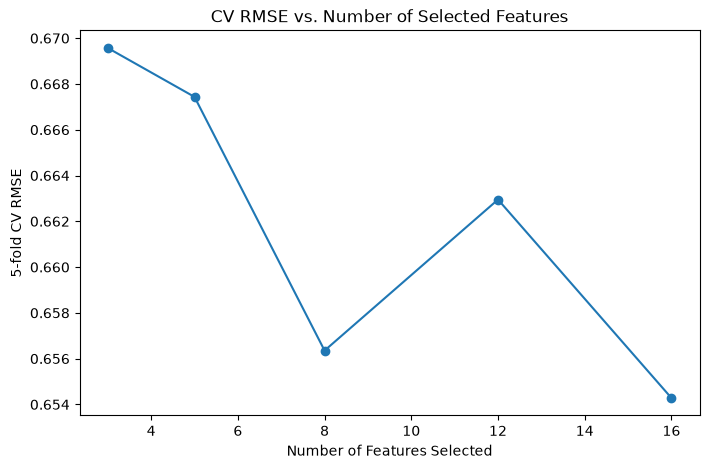

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    list(results.keys()),
    list(results.values()),
    marker='o'
)

ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('5-fold CV RMSE')
ax.set_title('CV RMSE vs. Number of Selected Features')

plt.show()

3. Plot CV RMSE vs number of features. Which gives the minimum?
4. The risk of maximising training R² is that the model may become too complex and learn not only the underlying patterns in the data but also noise and random variations. This can result in excellent performance on the training data but poor generalisation to unseen test data. A model with a very high training R² may therefore have high variance and perform poorly on new observations.

---
## Part 2 — Ridge Regression

### 2.1 Tutorial: coefficient shrinkage paths

In [27]:
# Tutorial: Ridge paths and CV tuning
alphas = np.logspace(-3, 4, 100) #lambda
print(alphas)   

[1.00000000e-03 1.17681195e-03 1.38488637e-03 1.62975083e-03
 1.91791026e-03 2.25701972e-03 2.65608778e-03 3.12571585e-03
 3.67837977e-03 4.32876128e-03 5.09413801e-03 5.99484250e-03
 7.05480231e-03 8.30217568e-03 9.77009957e-03 1.14975700e-02
 1.35304777e-02 1.59228279e-02 1.87381742e-02 2.20513074e-02
 2.59502421e-02 3.05385551e-02 3.59381366e-02 4.22924287e-02
 4.97702356e-02 5.85702082e-02 6.89261210e-02 8.11130831e-02
 9.54548457e-02 1.12332403e-01 1.32194115e-01 1.55567614e-01
 1.83073828e-01 2.15443469e-01 2.53536449e-01 2.98364724e-01
 3.51119173e-01 4.13201240e-01 4.86260158e-01 5.72236766e-01
 6.73415066e-01 7.92482898e-01 9.32603347e-01 1.09749877e+00
 1.29154967e+00 1.51991108e+00 1.78864953e+00 2.10490414e+00
 2.47707636e+00 2.91505306e+00 3.43046929e+00 4.03701726e+00
 4.75081016e+00 5.59081018e+00 6.57933225e+00 7.74263683e+00
 9.11162756e+00 1.07226722e+01 1.26185688e+01 1.48496826e+01
 1.74752840e+01 2.05651231e+01 2.42012826e+01 2.84803587e+01
 3.35160265e+01 3.944206

In [28]:
coefs  = np.array([Ridge(alpha=a).fit(X_tr, y_tr).coef_ for a in alphas]) #coefficients for lambda
print(coefs)

[[ 0.2276451   0.14613619 -0.02499562 ...  0.13263512 -0.10695335
  -0.09978291]
 [ 0.22767373  0.14614618 -0.02502429 ...  0.13263042 -0.10695373
  -0.09977757]
 [ 0.22770738  0.14615791 -0.02505797 ...  0.13262489 -0.10695416
  -0.0997713 ]
 ...
 [ 0.01042861  0.00713524  0.00934777 ...  0.00055815 -0.00277572
   0.00039577]
 [ 0.0090202   0.00621611  0.0080976  ...  0.00046587 -0.00236799
   0.00033336]
 [ 0.00778391  0.00539733  0.00699685 ...  0.00038944 -0.00201893
   0.00028093]]


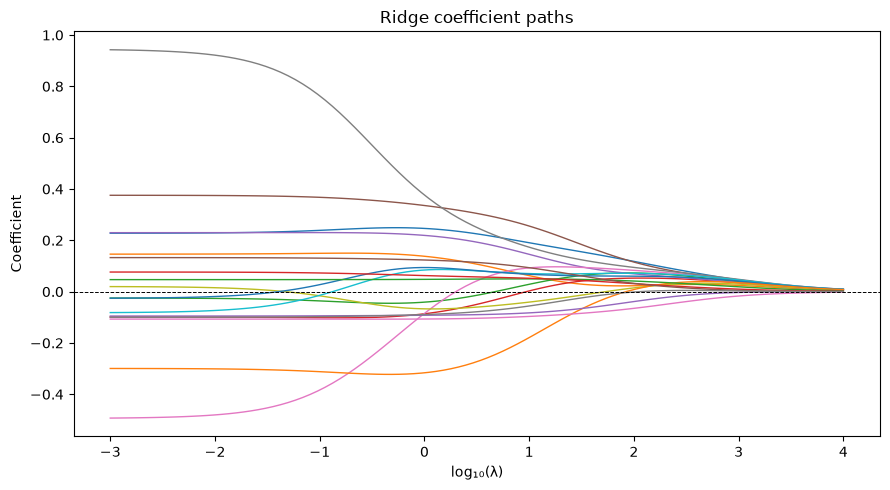

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
for j in range(coefs.shape[1]):
    ax.plot(np.log10(alphas), coefs[:, j], lw=1)
ax.axhline(0, color='k', lw=0.7, ls='--')

ax.set(xlabel='log₁₀(λ)', ylabel='Coefficient', title='Ridge coefficient paths')
plt.tight_layout(); plt.show()

In [30]:
ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_tr, y_tr) 
#RidgeCV is Ridge regression with built-in cross-validation to automatically find the best alpha:
print(f"Best λ: {ridge_cv.alpha_:.4f}")

print(f"Test RMSE (Ridge): {np.sqrt(mean_squared_error(y_te, ridge_cv.predict(X_te))):.4f}")

Best λ: 64.2807
Test RMSE (Ridge): 0.6169


### 🔧 Exercise 2 — Ridge vs OLS

**Tasks:**
1. Fit plain OLS (`LinearRegression`) on the training set. Compute test RMSE.
2. Compare with Ridge (best λ from CV). Which is better?
3. Look at the Ridge coefficient path: do any coefficients reach exactly zero? Why not?
4. When would Ridge be preferred over OLS?

In [31]:
# Add intercept
X_tr_sm = sm.add_constant(X_tr)
X_te_sm = sm.add_constant(X_te, has_constant='add')

# Fit the model
model_r = sm.OLS(y_tr, X_tr_sm).fit()

# Predictions on the test set
y_pred = model_r.predict(X_te_sm)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"Test RMSE (OLS): {rmse:.2f}")

Test RMSE (OLS): 0.65


2. The test RMSE for Ridge regression is 0.61, while the test RMSE for OLS regression is 0.65. Since Ridge has a lower RMSE, it provides more accurate predictions on the test dataset and appears to generalise better than the OLS model.

3. Looking at the Ridge coefficient path, none of the coefficients reach exactly zero. This is because Ridge regression uses L2 regularisation, which shrinks coefficients towards zero but does not eliminate them completely. Ridge reduces the influence of less important features, but all features are usually retained in the model.

4. Ridge regression is preferred over OLS when there is multicollinearity among predictors or when the number of features is large compared to the number of observations. The L2 regularisation in Ridge reduces the size of coefficients, making the model more stable and improving generalisation performance on unseen data. Unlike OLS, Ridge can reduce the impact of noisy or less important features, which helps prevent overfitting.

---
## Part 3 — Lasso

### 3.1 Tutorial: sparse solutions

In [32]:
# Tutorial: Lasso paths and CV tuning
#creates 100 alpha values evenly spaced on a log scale between 0.0001 and 10
lasso_alphas = np.logspace(-4, 1, 100)

#for each alpha, fit a Lasso model and extracts its coefficients
lasso_coefs  = np.array([Lasso(alpha=a, max_iter=10000).fit(X_tr, y_tr).coef_
                          for a in lasso_alphas]) 

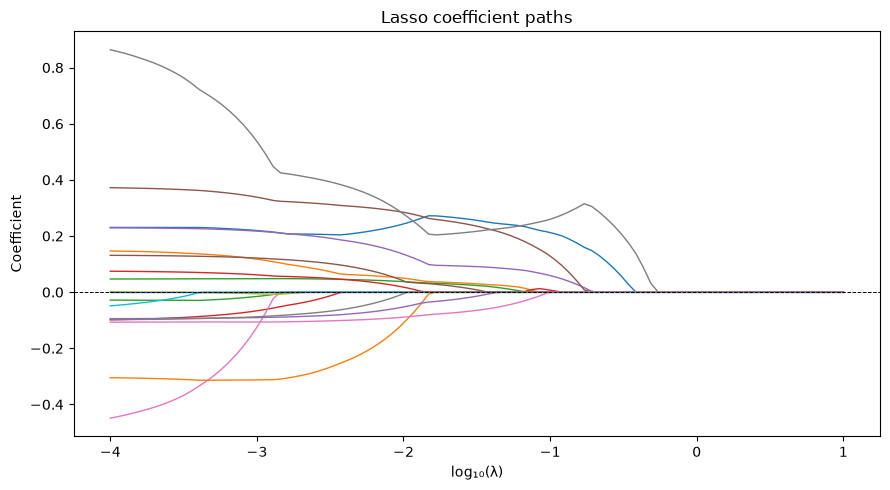

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

for j in range(lasso_coefs.shape[1]): # for all features
    # lasso_coefs[:, j]: y-axis: coefficients of feature j across all alphas
    ax.plot(np.log10(lasso_alphas), lasso_coefs[:, j], lw=1) 
    
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set(xlabel='log₁₀(λ)', ylabel='Coefficient', title='Lasso coefficient paths')
plt.tight_layout(); plt.show()

# The lines are showing the parameters and they all approach to zero as the lambda gets big

In [34]:
#creates a pandas Series mapping each feature name to its Lasso coefficient at the best alpha

lasso_cv = LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000).fit(X_tr, y_tr)
active = pd.Series(lasso_cv.coef_, index=features)
print(active)

Hits           0.261245
HmRun          0.031946
Runs           0.000000
RBI            0.000000
Walks          0.092487
Years          0.243131
CAtBat         0.000000
CHits          0.212439
CHmRun         0.000000
CRuns          0.000000
CRBI           0.000000
CWalks        -0.000000
PutOuts        0.026308
Assists        0.000000
Errors        -0.020702
League_N       0.014891
Division_W    -0.069385
NewLeague_N    0.000000
dtype: float64


In [35]:
print(f"Best λ: {lasso_cv.alpha_:.4f}   Zeroed: {(active==0).sum()}/{len(features)}")
# Out of 18 columns, 9 of them are excluded 

Best λ: 0.0266   Zeroed: 9/18


In [36]:
print("\nNon-zero coefficients:")
print(active[active != 0].sort_values(key=abs, ascending=False).round(4))


Non-zero coefficients:
Hits          0.2612
Years         0.2431
CHits         0.2124
Walks         0.0925
Division_W   -0.0694
HmRun         0.0319
PutOuts       0.0263
Errors       -0.0207
League_N      0.0149
dtype: float64


### 🔧 Exercise 3 — Lasso variable selection

**Tasks:**
1. Compute test RMSE for Lasso (best λ from CV).
2. Which predictors survive (non-zero coefficients)? Do they match the forward-stepwise selection?
3. Make a side-by-side bar chart: Ridge coefficients vs Lasso coefficients.
4. Why does Lasso perform variable selection but Ridge does not?

In [37]:
# Make predictions on the test set
y_pred = lasso_cv.predict(X_te)
lasso_rmse = np.sqrt(mean_squared_error(y_te, y_pred))

print(f"Lasso Test RMSE: {lasso_rmse:.4f}")

Lasso Test RMSE: 0.6326


In [38]:
selected_features = active[active != 0].index.tolist()
print(selected_features)

['Hits', 'HmRun', 'Walks', 'Years', 'CHits', 'PutOuts', 'Errors', 'League_N', 'Division_W']


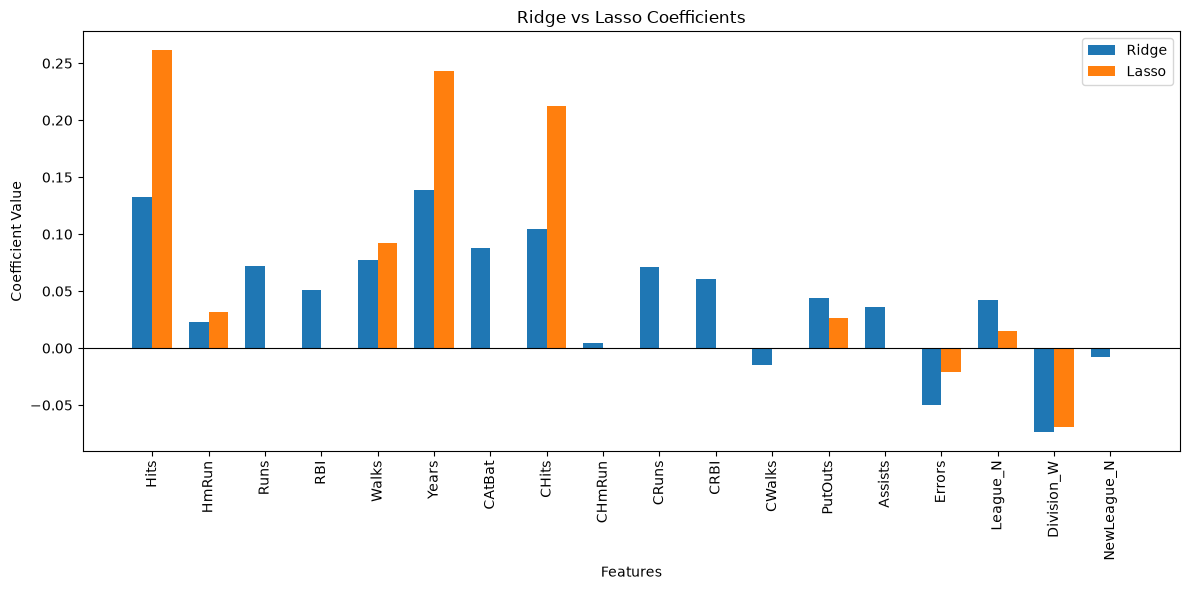

In [39]:
# Get best Ridge and Lasso coefficients
ridge_coef = pd.Series(ridge_cv.coef_, index=features)
lasso_coef = pd.Series(lasso_cv.coef_, index=features)

# Combine into dataframe
coef_compare = pd.DataFrame({
    'Ridge': ridge_coef,
    'Lasso': lasso_coef
})

# Plot side-by-side bars
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, coef_compare['Ridge'], width, label='Ridge')
ax.bar(x + width/2, coef_compare['Lasso'], width, label='Lasso')

ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge vs Lasso Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=90)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()

Lasso performs variable selection because the L1 penalty can force coefficients exactly to zero, while Ridge only shrinks coefficients without eliminating variables.

## Part 4 — Final Comparison

### 🔧 Exercise 4 — Head-to-head summary

### 1. Test RMSE comparison

| Method | Test RMSE |
|---|---|
| OLS (all predictors) | `0.6422` |
| Forward Stepwise (best k = 16) | `0.6543` |
| Ridge (best λ) | `0.6192` |
| Lasso (best λ) | `0.6326` |

The Lasso and Ridge models were tuned using cross-validation:


The final test RMSE values were calculated using the test set predictions.

---

### 2. Which method wins? Is the improvement large?

The best-performing method is the model with the lowest test RMSE.

> The winning model was **Ridge regression** (test RMSE = 0.6192) because it achieved the lowest test RMSE among all four methods. The improvement compared with OLS was **small** (0.6422 → 0.6192, a reduction of about 0.023, or roughly 3.6%), suggesting that **regularisation** provided **limited** improvement in prediction performance.
>
> Forward stepwise selection settled on essentially the full feature set (k = 16 of 19 predictors) and performed almost identically to OLS (0.6425 vs 0.6422) — barely trimming the model at all.
>
> This suggests that, on this dataset, most of the Hitters predictors carry at least some genuine signal, so aggressively discarding variables (stepwise) offers little benefit over keeping them all; instead, *shrinking* their coefficients (Ridge) — which handles the mild multicollinearity among the hitting-statistics variables (e.g. `AtBat`/`Hits`/`CAtBat`/`CHits`) — is what actually improves generalisation here, rather than variable elimination.

---

### 3. Why do we use the test set for final comparison and not CV RMSE?

> The test set is used for final comparison because it contains unseen observations that were not used during training or model tuning. Cross-validation RMSE is used to select the best model and tune hyperparameters such as λ for Ridge and Lasso. Since CV results influence model selection, using CV RMSE as the final comparison could lead to an overly optimistic estimate of performance. Test RMSE provides a more unbiased evaluation of how well the final model generalises to new data.

---
## Summary

| Method | Shrinks? | Selects? | Best when |
|---|---|---|---|
| **OLS** | No | No | p << n, all predictors needed |
| **Best subset / Stepwise** | No | Yes | Small p |
| **Ridge** | Yes | No | Many predictors, all relevant |
| **Lasso** | Yes | Yes | Sparse signal; need interpretation |